# Phase 3: Logistic Regression — The Statistical Way

**Project:** Credit Default Risk Modeling  
**Phase:** 3 — Statistical Logistic Regression with Full Interpretation  

---

## Why `statsmodels` and NOT `sklearn`?

| | `sklearn` | `statsmodels` |
|---|---|---|
| Purpose | Prediction | Statistical inference |
| p-values |  No |  Yes |
| Confidence intervals |  No |  Yes |
| Odds ratios |  No |  Yes |
| Wald test |  No |  Yes |
| AIC / BIC |  No |  Yes |
| Interview credibility | Low |  High |

In finance and risk, you must **explain WHY** a model makes decisions.  
`statsmodels` gives you the statistical machinery to do exactly that.

---

##  The Math Behind Logistic Regression

**Log-odds (Logit) function:**
$$\text{logit}(p) = \ln\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_k x_k$$

**Probability:**
$$P(\text{Default}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \cdots)}}$$

**Odds Ratio for coefficient** $\beta_i$:
$$OR_i = e^{\beta_i}$$

**Interpretation:**  
A 1-unit increase in $x_i$ multiplies the **odds of default** by $e^{\beta_i}$

## 1 Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, precision_recall_curve
)
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2 Load & Prepare Data

In [3]:
data = pd.read_csv('/home/vidit/Public/Project/Customer Churn Prediction/Data/german_credit_data.csv')

column_mapping = {
    'laufkont':'checking_account', 'laufzeit':'duration_months',
    'moral':'credit_history',      'verw':'purpose',
    'hoehe':'credit_amount',       'sparkont':'savings_account',
    'beszeit':'employment_years',  'rate':'installment_rate',
    'famges':'personal_status',    'buerge':'other_debtors',
    'wohnzeit':'residence_years',  'verm':'property',
    'alter':'age',                 'weitkred':'other_installments',
    'wohn':'housing',              'bishkred':'existing_credits',
    'beruf':'job',                 'pers':'dependents',
    'telef':'telephone',           'gastarb':'foreign_worker',
    'kredit':'target'
}
data.rename(columns=column_mapping, inplace=True)

raw_vals = sorted(data['target'].unique())
if set(raw_vals) == {1, 2}:
    data['target'] = data['target'].map({1: 0, 2: 1})
elif set(raw_vals) == {0, 1}:
    data['target'] = data['target'].map({1: 0, 0: 1})

print(f'Shape: {data.shape}')
print(f'Default Rate: {data["target"].mean()*100:.1f}%')
print('Data ready for analysis.')

Shape: (1000, 21)
Default Rate: 30.0%
Data ready for analysis.


## 3 WoE Encoding (from Phase 1)

We use WoE-encoded features as input to logistic regression.  
This is the **standard credit scoring pipeline**.

In [5]:
# ── Confirmed significant features from Phase 2 ────────────────────────────
numeric_selected = ['duration_months', 'credit_amount', 'age', 'installment_rate']

categorical_selected = [
    'checking_account', 'credit_history', 'purpose', 'savings_account',
    'employment_years', 'personal_status', 'other_debtors', 'property',
    'other_installments', 'housing', 'foreign_worker'
]

selected_features = numeric_selected + categorical_selected


# ── WoE functions (from Phase 1) ───────────────────────────────────────────
def compute_woe_iv(df, feature, target, bins=10, is_numeric=True):
    df = df[[feature, target]].copy()
    total_events     = df[target].sum()
    total_non_events = len(df) - total_events
    if is_numeric:
        df['bin'] = pd.qcut(df[feature], q=bins, duplicates='drop')
    else:
        df['bin'] = df[feature]
    grouped = df.groupby('bin', observed=True)[target].agg(
        Events='sum', Total='count').reset_index()
    grouped['NonEvents'] = grouped['Total'] - grouped['Events']
    eps = 0.5
    grouped['pct_Events']    = (grouped['Events']    + eps) / (total_events     + eps)
    grouped['pct_NonEvents'] = (grouped['NonEvents'] + eps) / (total_non_events + eps)
    grouped['WoE'] = np.log(grouped['pct_Events'] / grouped['pct_NonEvents'])
    grouped['IV']  = (grouped['pct_Events'] - grouped['pct_NonEvents']) * grouped['WoE']
    grouped['Default_Rate'] = grouped['Events'] / grouped['Total']
    return grouped[['bin','Total','Events','NonEvents','Default_Rate','WoE','IV']].round(4), round(grouped['IV'].sum(),4)


def apply_woe_encoding(df, features, target, numeric_cols, bins=10):
    df_woe = df.copy()
    woe_maps = {}
    for feature in features:
        is_num = feature in numeric_cols
        try:
            woe_df, _ = compute_woe_iv(df, feature, target, bins=bins, is_numeric=is_num)
            if is_num:
                df_woe[f'{feature}_bin'] = pd.qcut(df[feature], q=bins, duplicates='drop')
                woe_map = woe_df.set_index('bin')['WoE'].to_dict()
                df_woe[f'{feature}_woe'] = df_woe[f'{feature}_bin'].map(woe_map)
                df_woe.drop(columns=[f'{feature}_bin'], inplace=True)
            else:
                woe_map = woe_df.set_index('bin')['WoE'].to_dict()
                df_woe[f'{feature}_woe'] = df[feature].map(woe_map)
            woe_maps[feature] = woe_map
        except Exception as e:
            print(f'    Skipped {feature}: {e}')
    return df_woe, woe_maps


# Apply WoE encoding
df_woe, woe_maps = apply_woe_encoding(data, selected_features, 'target', numeric_selected)
woe_cols = [f'{f}_woe' for f in selected_features if f'{f}_woe' in df_woe.columns]

print(f'WoE encoding done   →  {len(woe_cols)} encoded features')

WoE encoding done   →  15 encoded features


## 4 Assumption Check 1 — Multicollinearity (VIF)

**Variance Inflation Factor (VIF)** measures how much a feature's variance is inflated by correlation with other features.

$$VIF_i = \frac{1}{1 - R^2_i}$$

| VIF | Interpretation |
|---|---|
| 1 | No correlation |
| 1 – 5 | Moderate — acceptable  |
| 5 – 10 | High — investigate  |
| > 10 | Severe multicollinearity  |

In [6]:
X_vif = df_woe[woe_cols].dropna()
X_vif_const = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF']     = [variance_inflation_factor(X_vif.values, i)
                        for i in range(X_vif.shape[1])]
vif_data['Status']  = vif_data['VIF'].apply(
    lambda v: ' OK' if v < 5 else (' High' if v < 10 else ' Severe')
)
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print('=== Variance Inflation Factor (VIF) ===\n')
print(vif_data.to_string(index=False))
print('\nFeatures with VIF > 5 should be investigated for multicollinearity')

=== Variance Inflation Factor (VIF) ===

               Feature      VIF Status
          property_woe 1.365403     OK
   duration_months_woe 1.277725     OK
     credit_amount_woe 1.271906     OK
           housing_woe 1.248371     OK
  checking_account_woe 1.161047     OK
    credit_history_woe 1.139656     OK
               age_woe 1.119119     OK
   personal_status_woe 1.114236     OK
  employment_years_woe 1.112532     OK
other_installments_woe 1.093586     OK
  installment_rate_woe 1.081708     OK
   savings_account_woe 1.080439     OK
    foreign_worker_woe 1.057169     OK
           purpose_woe 1.052362     OK
     other_debtors_woe 1.037140     OK

Features with VIF > 5 should be investigated for multicollinearity


## 5 Assumption Check 2 — Linearity in Log-Odds (Box-Tidwell)

Logistic regression assumes that numeric features have a **linear relationship with the log-odds** of the outcome.

**Box-Tidwell Test:** Add interaction term $x \cdot \ln(x)$ to the model.  
If the interaction is significant (p < 0.05) → linearity assumption violated.

In [7]:
# We test on raw numeric features (before WoE) — WoE encoding already
# linearizes the relationship, so this is informational

print('=== Box-Tidwell Test — Linearity in Log-Odds ===\n')
print('Note: WoE encoding already linearizes numeric features.')
print('This test is shown for completeness/interview awareness.\n')

numeric_raw = ['duration_months', 'credit_amount', 'age', 'installment_rate']
df_bt = data[numeric_raw + ['target']].dropna().copy()

# Add interaction terms x * ln(x)
for col in numeric_raw:
    df_bt[col] = df_bt[col].clip(lower=0.01)   # avoid log(0)
    df_bt[f'{col}_ln'] = df_bt[col] * np.log(df_bt[col])

bt_features = numeric_raw + [f'{c}_ln' for c in numeric_raw]
X_bt = sm.add_constant(df_bt[bt_features])
y_bt = df_bt['target']

bt_model = sm.Logit(y_bt, X_bt).fit(disp=0)

print(f'{"Feature":<25} {"Coef":>10} {"p-value":>10} {"Linear?"}')
print('-' * 55)
for col in numeric_raw:
    key  = f'{col}_ln'
    coef = bt_model.params.get(key, np.nan)
    pval = bt_model.pvalues.get(key, np.nan)
    linear = ' Yes' if pval >= 0.05 else '  Violated'
    print(f'{key:<25} {coef:>10.4f} {pval:>10.4f}   {linear}')

print('\n Violated features: consider WoE binning or polynomial terms')
print('   (WoE encoding in our pipeline already handles this)')

=== Box-Tidwell Test — Linearity in Log-Odds ===

Note: WoE encoding already linearizes numeric features.
This test is shown for completeness/interview awareness.

Feature                         Coef    p-value Linear?
-------------------------------------------------------
duration_months_ln           -0.0466     0.0303     Violated
credit_amount_ln              0.0002     0.0013     Violated
age_ln                        0.1030     0.0060     Violated
installment_rate_ln           0.2257     0.5641    Yes

 Violated features: consider WoE binning or polynomial terms
   (WoE encoding in our pipeline already handles this)


## 6 Train/Test Split

In [8]:
df_model = df_woe[woe_cols + ['target']].dropna()

X = df_model[woe_cols]
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {len(X_train)}  (default rate: {y_train.mean()*100:.1f}%)')
print(f'Test size  : {len(X_test)}   (default rate: {y_test.mean()*100:.1f}%)')
print(' Stratified split — default rate preserved in both sets')

Train size : 800  (default rate: 30.0%)
Test size  : 200   (default rate: 30.0%)
 Stratified split — default rate preserved in both sets


## 7 Fit Logistic Regression with `statsmodels`

This gives us the **full statistical output** — p-values, confidence intervals, AIC, log-likelihood.

In [9]:
# Add intercept (statsmodels doesn't add it automatically)
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

# Fit logistic regression
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit(method='newton', maxiter=100, disp=True)

print('\nModel fitted successfully.')

Optimization terminated successfully.
         Current function value: 0.446245
         Iterations 7

Model fitted successfully.


In [10]:
# Full statistical summary
print(result.summary2())

                            Results: Logit
Model:                 Logit             Method:            MLE       
Dependent Variable:    target            Pseudo R-squared:  0.269     
Date:                  2026-03-09 17:15  AIC:               745.9914  
No. Observations:      800               BIC:               820.9452  
Df Model:              15                Log-Likelihood:    -357.00   
Df Residuals:          784               LL-Null:           -488.69   
Converged:             1.0000            LLR p-value:       2.1486e-47
No. Iterations:        7.0000            Scale:             1.0000    
----------------------------------------------------------------------
                        Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
----------------------------------------------------------------------
const                  -0.9197   0.0975 -9.4358 0.0000 -1.1108 -0.7287
duration_months_woe     0.7954   0.2055  3.8700 0.0001  0.3926  1.1983
credit_amount_woe       0.7782   0

## 8 Coefficient Interpretation — Odds Ratios

This is the most important output for finance interviews.

**Recall:**  
- Coefficient $\beta$ → log-odds change per 1-unit WoE increase  
- Odds Ratio = $e^\beta$ → multiplicative effect on odds of default  
- OR > 1 → increases default odds  
- OR < 1 → decreases default odds

In [11]:
# Build odds ratio table
coef_df = pd.DataFrame({
    'Coefficient'  : result.params,
    'Std Error'    : result.bse,
    'z-stat'       : result.tvalues,
    'p-value'      : result.pvalues,
    'CI Lower'     : result.conf_int()[0],
    'CI Upper'     : result.conf_int()[1],
}).drop('const', errors='ignore')

coef_df['Odds Ratio']    = np.exp(coef_df['Coefficient'])
coef_df['OR CI Lower']   = np.exp(coef_df['CI Lower'])
coef_df['OR CI Upper']   = np.exp(coef_df['CI Upper'])
coef_df['Significant']   = coef_df['p-value'] < 0.05
coef_df['Direction']     = coef_df['Odds Ratio'].apply(
    lambda x: ' Increases Risk' if x > 1 else ' Decreases Risk'
)

coef_df = coef_df.sort_values('p-value')

print('=== Logistic Regression — Coefficients & Odds Ratios ===\n')
display_cols = ['Coefficient','p-value','Odds Ratio','OR CI Lower','OR CI Upper','Significant','Direction']
print(coef_df[display_cols].round(4).to_string())

=== Logistic Regression — Coefficients & Odds Ratios ===

                        Coefficient  p-value  Odds Ratio  OR CI Lower  OR CI Upper  Significant        Direction
checking_account_woe         0.8335   0.0000      2.3014       1.8108       2.9250         True   Increases Risk
purpose_woe                  1.0317   0.0000      2.8060       1.7717       4.4440         True   Increases Risk
credit_history_woe           0.8036   0.0000      2.2336       1.5501       3.2185         True   Increases Risk
savings_account_woe          0.9459   0.0001      2.5750       1.6109       4.1161         True   Increases Risk
duration_months_woe          0.7954   0.0001      2.2154       1.4808       3.3144         True   Increases Risk
installment_rate_woe         1.6314   0.0075      5.1108       1.5447      16.9094         True   Increases Risk
personal_status_woe          1.2171   0.0076      3.3774       1.3811       8.2590         True   Increases Risk
credit_amount_woe            0.7782   

## 9 Odds Ratio Forest Plot

The **forest plot** is standard in clinical and financial research to visualize coefficient confidence intervals.

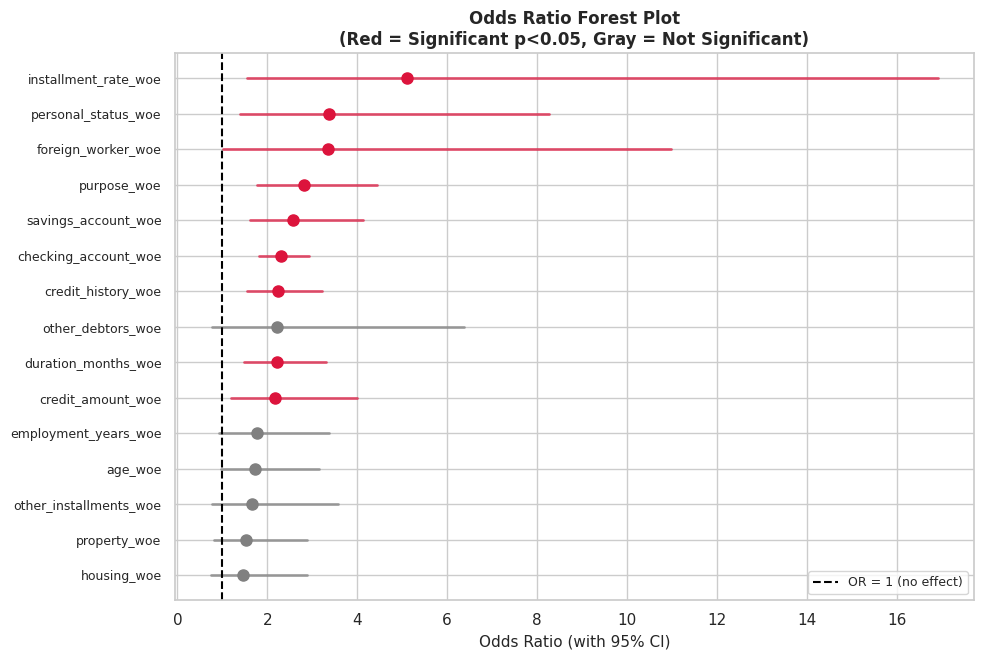

In [12]:
plot_df = coef_df.copy().reset_index()
plot_df.columns = ['Feature'] + list(plot_df.columns[1:])
plot_df = plot_df.sort_values('Odds Ratio', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(plot_df)*0.45)))

colors = ['crimson' if sig else 'gray' for sig in plot_df['Significant']]

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.plot([row['OR CI Lower'], row['OR CI Upper']], [i, i],
            color=colors[i], linewidth=2, alpha=0.7)
    ax.plot(row['Odds Ratio'], i, 'o',
            color=colors[i], markersize=8)

ax.axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='OR = 1 (no effect)')
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['Feature'], fontsize=9)
ax.set_xlabel('Odds Ratio (with 95% CI)', fontsize=11)
ax.set_title('Odds Ratio Forest Plot\n(Red = Significant p<0.05, Gray = Not Significant)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 10 Business Interpretation of Key Coefficients

This is what you say in interviews.

In [13]:
print('=== Business Interpretation of Key Coefficients ===\n')

top5 = coef_df[coef_df['Significant']].head(5)

for feat, row in top5.iterrows():
    feat_clean = feat.replace('_woe', '').replace('_', ' ').title()
    coef  = row['Coefficient']
    OR    = row['Odds Ratio']
    pval  = row['p-value']
    ci_lo = row['OR CI Lower']
    ci_hi = row['OR CI Upper']

    direction = 'INCREASES' if OR > 1 else 'DECREASES'
    pct_change = abs((OR - 1) * 100)

    print(f' {feat_clean}')
    print(f'   Coefficient : {coef:.4f}')
    print(f'   Odds Ratio  : {OR:.4f}  (95% CI: {ci_lo:.4f} – {ci_hi:.4f})')
    print(f'   p-value     : {pval:.4f}')
    print(f'   Interpretation: A 1-unit increase in WoE {direction} the odds of default')
    print(f'   by {pct_change:.1f}% (OR={OR:.3f}), holding all other features constant.')
    print()

=== Business Interpretation of Key Coefficients ===

 Checking Account
   Coefficient : 0.8335
   Odds Ratio  : 2.3014  (95% CI: 1.8108 – 2.9250)
   p-value     : 0.0000
   Interpretation: A 1-unit increase in WoE INCREASES the odds of default
   by 130.1% (OR=2.301), holding all other features constant.

 Purpose
   Coefficient : 1.0317
   Odds Ratio  : 2.8060  (95% CI: 1.7717 – 4.4440)
   p-value     : 0.0000
   Interpretation: A 1-unit increase in WoE INCREASES the odds of default
   by 180.6% (OR=2.806), holding all other features constant.

 Credit History
   Coefficient : 0.8036
   Odds Ratio  : 2.2336  (95% CI: 1.5501 – 3.2185)
   p-value     : 0.0000
   Interpretation: A 1-unit increase in WoE INCREASES the odds of default
   by 123.4% (OR=2.234), holding all other features constant.

 Savings Account
   Coefficient : 0.9459
   Odds Ratio  : 2.5750  (95% CI: 1.6109 – 4.1161)
   p-value     : 0.0001
   Interpretation: A 1-unit increase in WoE INCREASES the odds of default
   by 

## 11 Model Goodness-of-Fit

Unlike linear regression (R²), logistic regression uses pseudo-R² measures.

In [14]:
print('=== Model Goodness-of-Fit ===\n')

# McFadden's pseudo-R²
mcfadden_r2 = result.prsquared

# Null model log-likelihood
ll_null  = result.llnull
ll_model = result.llf

print(f'Log-Likelihood (Null)  : {ll_null:.4f}')
print(f'Log-Likelihood (Model) : {ll_model:.4f}')
print(f'McFadden Pseudo-R²     : {mcfadden_r2:.4f}')
print(f'AIC                    : {result.aic:.4f}')
print(f'BIC                    : {result.bic:.4f}')
print(f'LLR p-value            : {result.llr_pvalue:.6f}')

print()
print('McFadden R² Interpretation:')
if mcfadden_r2 < 0.1:
    print('  < 0.10 → Poor fit')
elif mcfadden_r2 < 0.2:
    print('  0.10–0.20 → Acceptable fit')
elif mcfadden_r2 < 0.4:
    print('  0.20–0.40 → Good fit ')
else:
    print('  > 0.40 → Excellent fit ')

print(f'\nLLR p-value < 0.05: {result.llr_pvalue < 0.05} → Model is significantly better than null')

=== Model Goodness-of-Fit ===

Log-Likelihood (Null)  : -488.6914
Log-Likelihood (Model) : -356.9957
McFadden Pseudo-R²     : 0.2695
AIC                    : 745.9914
BIC                    : 820.9452
LLR p-value            : 0.000000

McFadden R² Interpretation:
  0.20–0.40 → Good fit 

LLR p-value < 0.05: True → Model is significantly better than null


## 12 Predictions & Threshold Selection

In [15]:
# Predict probabilities
y_prob_train = result.predict(X_train_sm)
y_prob_test  = result.predict(X_test_sm)

# Default threshold = 0.5 — but we'll optimize below
y_pred_test  = (y_prob_test >= 0.5).astype(int)

print('=== Predictions at Threshold = 0.5 ===')
print(classification_report(y_test, y_pred_test,
                             target_names=['Good (0)', 'Default (1)']))

=== Predictions at Threshold = 0.5 ===
              precision    recall  f1-score   support

    Good (0)       0.80      0.88      0.84       140
 Default (1)       0.63      0.48      0.55        60

    accuracy                           0.76       200
   macro avg       0.71      0.68      0.69       200
weighted avg       0.75      0.76      0.75       200



## 13 ROC Curve & AUC

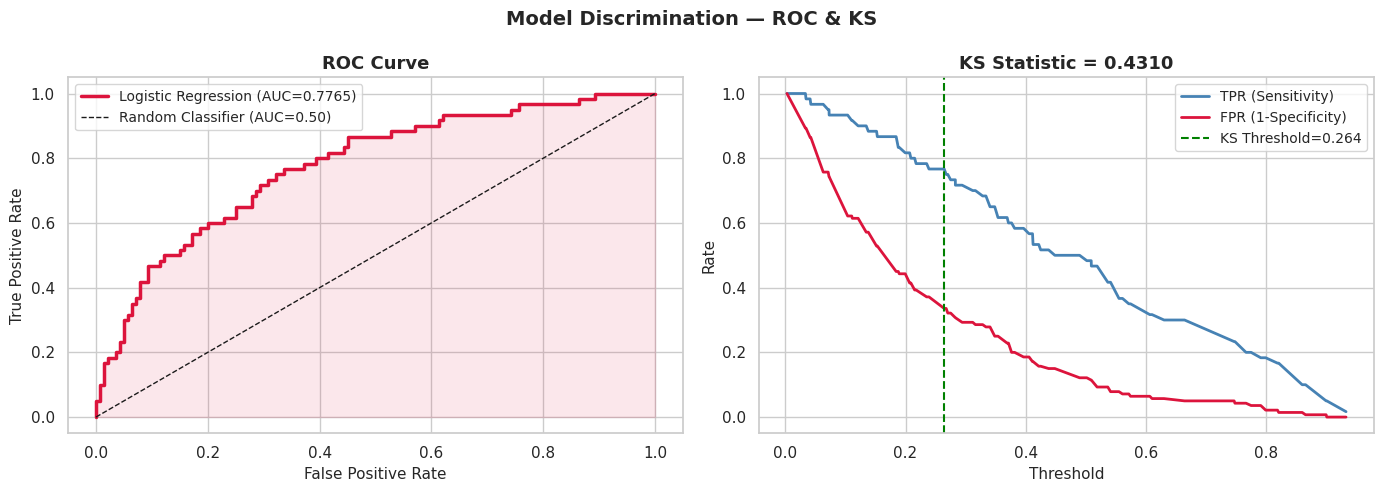

ROC-AUC      : 0.7765
KS Statistic : 0.4310
Gini Coeff   : 0.5531

KS Statistic Benchmarks (Finance):
  < 0.20 → Poor | 0.20–0.40 → Average | 0.40–0.60 → Good | > 0.60 → Excellent


In [16]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
auc = roc_auc_score(y_test, y_prob_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='crimson', linewidth=2.5, label=f'Logistic Regression (AUC={auc:.4f})')
axes[0].plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier (AUC=0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='crimson')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# KS Statistic (finance-specific metric)
ks_stat = max(tpr - fpr)
ks_idx  = np.argmax(tpr - fpr)
axes[1].plot(thresholds, tpr[:-1] if len(tpr)>len(thresholds) else tpr,
             color='steelblue', label='TPR (Sensitivity)', linewidth=2)
axes[1].plot(thresholds, fpr[:-1] if len(fpr)>len(thresholds) else fpr,
             color='crimson', label='FPR (1-Specificity)', linewidth=2)
axes[1].axvline(thresholds[ks_idx], color='green', linestyle='--',
                label=f'KS Threshold={thresholds[ks_idx]:.3f}')
axes[1].set_xlabel('Threshold', fontsize=11)
axes[1].set_ylabel('Rate', fontsize=11)
axes[1].set_title(f'KS Statistic = {ks_stat:.4f}', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Model Discrimination — ROC & KS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'ROC-AUC      : {auc:.4f}')
print(f'KS Statistic : {ks_stat:.4f}')
print(f'Gini Coeff   : {2*auc - 1:.4f}')
print()
print('KS Statistic Benchmarks (Finance):')
print('  < 0.20 → Poor | 0.20–0.40 → Average | 0.40–0.60 → Good | > 0.60 → Excellent')

## 14 Calibration Curve

**Calibration** measures whether predicted probabilities match actual default rates.  
A perfectly calibrated model: if it says 30% default probability, 30% of those actually defaulted.  
Finance teams care deeply about this — poorly calibrated models misprice risk.

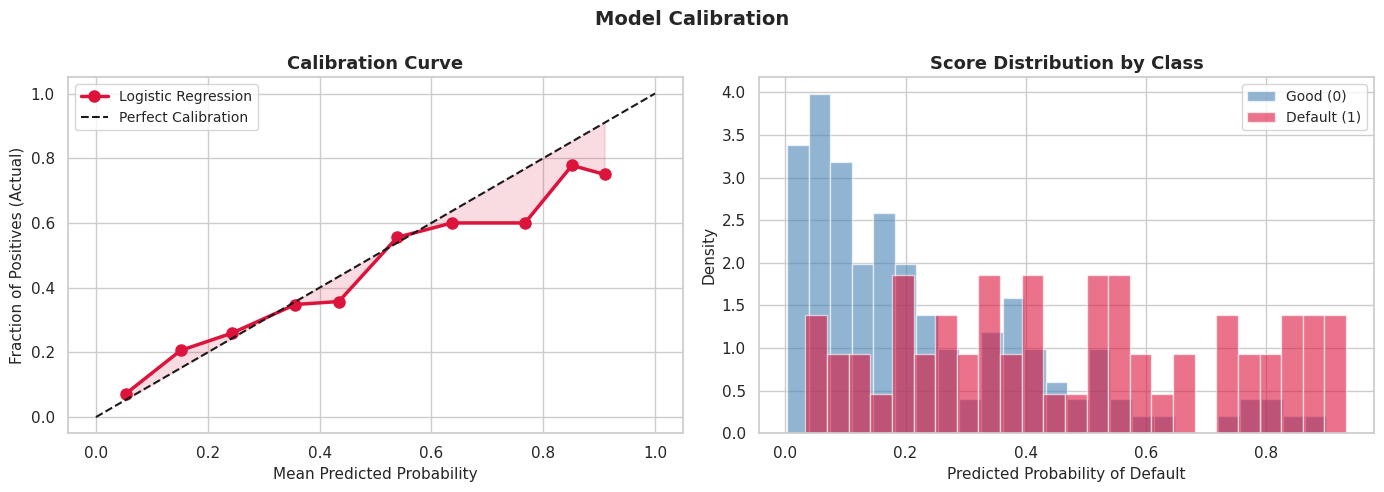

Brier Score: 0.1687  (lower is better; 0=perfect, 0.25=random)


In [17]:
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration curve
axes[0].plot(prob_pred, prob_true, 'o-', color='crimson', linewidth=2.5,
             markersize=8, label='Logistic Regression')
axes[0].plot([0,1], [0,1], 'k--', linewidth=1.5, label='Perfect Calibration')
axes[0].fill_between(prob_pred, prob_pred, prob_true, alpha=0.15, color='crimson')
axes[0].set_xlabel('Mean Predicted Probability', fontsize=11)
axes[0].set_ylabel('Fraction of Positives (Actual)', fontsize=11)
axes[0].set_title('Calibration Curve', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# Predicted probability distribution
axes[1].hist(y_prob_test[y_test==0], bins=25, alpha=0.6,
             color='steelblue', label='Good (0)', density=True)
axes[1].hist(y_prob_test[y_test==1], bins=25, alpha=0.6,
             color='crimson', label='Default (1)', density=True)
axes[1].set_xlabel('Predicted Probability of Default', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Score Distribution by Class', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Model Calibration', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calibration error (Brier score)
from sklearn.metrics import brier_score_loss
brier = brier_score_loss(y_test, y_prob_test)
print(f'Brier Score: {brier:.4f}  (lower is better; 0=perfect, 0.25=random)')

## 15 Confusion Matrix — Business Cost Analysis

In credit risk, errors are NOT equal:
- **False Negative** (missed default) = Bank loses the loan amount 
- **False Positive** (wrongly rejected) = Bank loses potential profit 

Typically: Cost(FN) >> Cost(FP)

Optimal threshold (cost-sensitive): 0.18
Business cost assumption: FN=5x more costly than FP



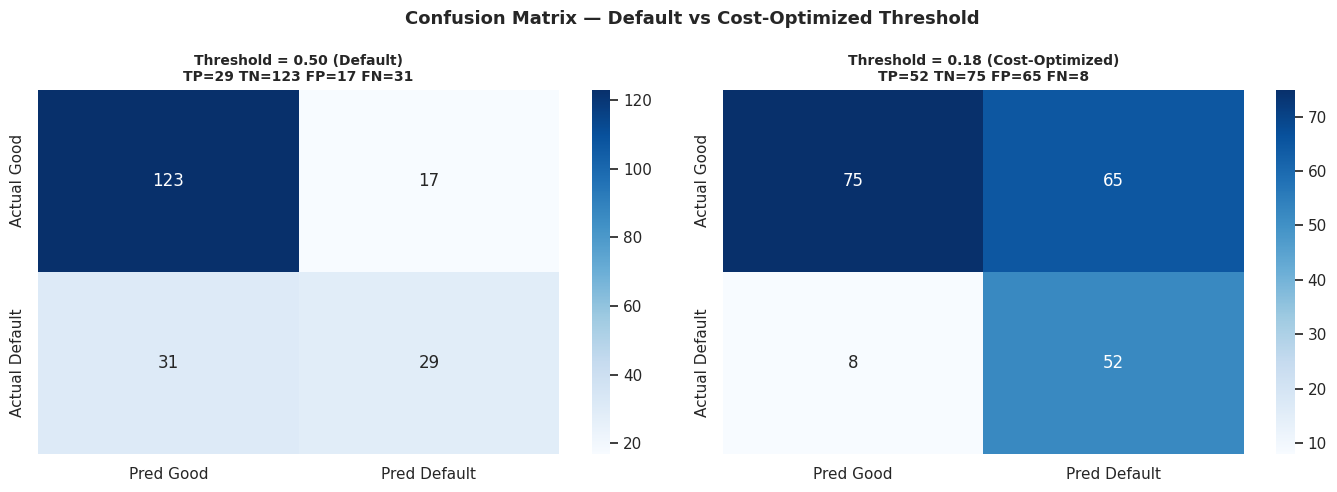


=== Classification Report (Cost-Optimized Threshold) ===
              precision    recall  f1-score   support

    Good (0)       0.90      0.54      0.67       140
 Default (1)       0.44      0.87      0.59        60

    accuracy                           0.64       200
   macro avg       0.67      0.70      0.63       200
weighted avg       0.77      0.64      0.65       200



In [18]:
COST_FN = 5   # missed default costs 5x more than false rejection
COST_FP = 1

# Find optimal threshold by minimizing business cost
thresholds_range = np.arange(0.1, 0.9, 0.01)
costs = []
for thresh in thresholds_range:
    y_pred_t = (y_prob_test >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    cost = COST_FN * fn + COST_FP * fp
    costs.append(cost)

optimal_idx   = np.argmin(costs)
optimal_thresh = thresholds_range[optimal_idx]
y_pred_optimal = (y_prob_test >= optimal_thresh).astype(int)

print(f'Optimal threshold (cost-sensitive): {optimal_thresh:.2f}')
print(f'Business cost assumption: FN={COST_FN}x more costly than FP\n')

# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, thresh, title in [
    (axes[0], 0.5, 'Threshold = 0.50 (Default)'),
    (axes[1], optimal_thresh, f'Threshold = {optimal_thresh:.2f} (Cost-Optimized)')
]:
    y_pred_t = (y_prob_test >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Good','Pred Default'],
                yticklabels=['Actual Good','Actual Default'])
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{title}\nTP={tp} TN={tn} FP={fp} FN={fn}',
                 fontweight='bold', fontsize=10)

plt.suptitle('Confusion Matrix — Default vs Cost-Optimized Threshold',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== Classification Report (Cost-Optimized Threshold) ===')
print(classification_report(y_test, y_pred_optimal,
                             target_names=['Good (0)', 'Default (1)']))

## 16 Phase 3 Summary

In [19]:
auc_val  = roc_auc_score(y_test, y_prob_test)
gini_val = 2 * auc_val - 1
ks_val   = max(tpr - fpr)

print('=' * 60)
print('PHASE 3 SUMMARY — LOGISTIC REGRESSION (statsmodels)')
print('=' * 60)
print(f'\n Model Performance (Test Set):')
print(f'   ROC-AUC      : {auc_val:.4f}')
print(f'   Gini Coeff   : {gini_val:.4f}')
print(f'   KS Statistic : {ks_val:.4f}')
print(f'   Brier Score  : {brier:.4f}')
print(f'\n Statistical Fit:')
print(f'   McFadden R²  : {result.prsquared:.4f}')
print(f'   AIC          : {result.aic:.2f}')
print(f'   LLR p-value  : {result.llr_pvalue:.6f}')
print(f'\n Optimal Decision Threshold : {optimal_thresh:.2f}')
print(f'   (Cost-optimized: FN penalty = {COST_FN}x FP penalty)')
print(f'\n Significant Features      : {coef_df["Significant"].sum()}/{len(coef_df)}')

PHASE 3 SUMMARY — LOGISTIC REGRESSION (statsmodels)

 Model Performance (Test Set):
   ROC-AUC      : 0.7765
   Gini Coeff   : 0.5531
   KS Statistic : 0.4310
   Brier Score  : 0.1687

 Statistical Fit:
   McFadden R²  : 0.2695
   AIC          : 745.99
   LLR p-value  : 0.000000

 Optimal Decision Threshold : 0.18
   (Cost-optimized: FN penalty = 5x FP penalty)

 Significant Features      : 9/15


## 📝 Phase 3 — Key Interview Talking Points

**On choosing statsmodels:**  
*"I used statsmodels instead of sklearn because in credit risk, model interpretability is a regulatory requirement. I need p-values, confidence intervals, and odds ratios to explain every coefficient to stakeholders — sklearn doesn't provide these."*

**On odds ratios:**  
*"Each coefficient represents the change in log-odds per unit change in the WoE-encoded feature. An odds ratio of 1.5 means a 1-unit increase in that feature multiplies the odds of default by 1.5 — a 50% increase — holding everything else constant."*

**On KS statistic:**  
*"KS statistic measures the maximum separation between the cumulative distributions of scores for Good and Default customers. Banks use this as a primary model discrimination metric — a KS above 0.40 is considered good."*

**On calibration:**  
*"A model with good AUC but poor calibration is dangerous in finance — it ranks customers correctly but the absolute probabilities are wrong, leading to incorrect loan pricing and provisioning. I always check the calibration curve."*

**On threshold optimization:**  
*"The default 0.5 threshold ignores business costs. In credit risk, a missed default (false negative) is far more costly than a rejected good customer (false positive), so I shifted the threshold to minimize total business cost."*

---
**Next Phase:** Advanced Modeling — Random Forest + XGBoost + model comparison table